<a href="https://colab.research.google.com/github/Marcelo-Silvestre/Analise_Dados_Boas_Praticas_PUCRIO/blob/main/Notebooks/MVP_Analise_Dados_Boas_Praticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Análise descritiva de ocorrências criminais no país entre 2015 e 2022.

**Nome:** Marcelo Alexandre Machado Silvestre

**Matrícula:** 4052025001857

**Datasets:** [Ocorrências Criminais SINESP](https://dados.gov.br/dados/conjuntos-dados/sistema-nacional-de-estatisticas-de-seguranca-publica) e [População IBGE](https://ftp.ibge.gov.br/Projecao_da_Populacao/Projecao_da_Populacao_2018/projecoes_2018_populacao_2010_2060_20200406.xls)



# 1 - Problema a analisar

A criminalidade no Brasil apresenta diferenças relevantes entre estados, tipos de crime e períodos do tempo. Uma análise baseada apenas em valores absolutos pode induzir a conclusões equivocadas, já que estados com maior população tendem a registrar maior número absoluto de ocorrências.

Diante disso, este MVP busca analisar o comportamento da criminalidade no Brasil entre 2015 e 2022, integrando dados de ocorrências criminais e dados populacionais para construir indicadores proporcionais e extrair padrões temporais, regionais e comparativos.

O foco do trabalho está na análise exploratória e no pré-processamento, com a criação de variáveis derivadas que melhorem a interpretação dos dados e possibilitem análises mais robustas.

### Premissas e restrições

As seguintes premissas e restrições foram adotadas:

- Os dados foram obtidos de fontes oficiais, o que aumenta sua confiabilidade.
- A análise considera o período de 2015 a 2022, pois esse intervalo está disponível em ambas as bases de forma compatível.
- A população utilizada é anual, projetada pelo IBGE, e será empregada como denominador para o cálculo da taxa por 100 mil habitantes.
- Possíveis subnotificações de crimes não são tratadas neste trabalho.
- O foco do notebook é analítico e exploratório, não contemplando modelagem preditiva final.


## 1.1 - Hipóteses

As hipóteses consideradas neste MVP são as seguintes:

1. Estados mais populosos não necessariamente apresentam as maiores taxas de criminalidade.
2. A padronização por população altera significativamente a interpretação dos resultados.
3. Existem diferenças temporais relevantes na evolução dos crimes.
4. Há diferenças regionais importantes nos padrões de criminalidade.
5. Alguns tipos de crime apresentam maior volatilidade que outros.


## 1.2 - Classificação

Este MVP se caracteriza principalmente como um problema de **análise exploratória de dados, com abordagem não supervisionada**, pois o objetivo central é compreender padrões, distribuições e relações entre variáveis, sem o treinamento de um modelo preditivo.

Trata-se, portanto, de um problema de análise descritiva com enfoque exploratório (EDA), sem aplicação de algoritmos de aprendizado de máquina nesta etapa.

Além disso, inclui a etapa de construção de atributos, em que foi criada uma variável categórica chamada **TENDENCIA**, construída a partir da variação da taxa de criminalidade ao longo do tempo. Essa variável poderá servir como *target* em estudos futuros de classificação.


# 2 - Seleção de Dados

As bases de dados para o projeto foram extraídas da fonte Dados Abertos do Governo Federal (SINESP) e da fonte de dados populacionais do IBGE. Os dados do SINESP correspondem a ocorrências de crimes por Unidade da Federação, enquanto os dados populacionais representam projeções anuais da população residente por UF.

Nesta etapa, são apresentadas as bibliotecas utilizadas, a carga das bases e a definição dos atributos que sustentam a análise.


## 2.1 - Importação das bibliotecas

Esta subseção reúne as bibliotecas necessárias para manipulação, inspeção, agregação e visualização dos dados ao longo do notebook.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


## 2.2 - Carga das bases de dados

Nesta etapa, as duas bases são carregadas diretamente a partir do repositório do projeto no GitHub para garantir reprodutibilidade da análise.


In [ ]:
# Base de ocorrências criminais
url_crimes = "https://raw.githubusercontent.com/Marcelo-Silvestre/Analise_Dados_Boas_Praticas_PUCRIO/main/Arquivos/indicadoressegurancapublicauf%20(1).xlsx"

# Base populacional do IBGE
url_pop = "https://raw.githubusercontent.com/Marcelo-Silvestre/Analise_Dados_Boas_Praticas_PUCRIO/main/Arquivos/IBGE_populacao__2010_2060.xlsx"

df_criminal = pd.read_excel(url_crimes)
df_pop_raw = pd.read_excel(url_pop)

print("Primeiras linhas da base criminal:")
display(df_criminal.head(2))
print()

print("\nPrimeiras linhas da base populacional original:")
display(df_pop_raw.head(2))


Primeiras linhas da base criminal:


,UF,Tipo Crime,Ano,Mês,Ocorrências
0,Acre,Estupro,2022,janeiro,31
1,Acre,Furto de veículo,2022,janeiro,50




Primeiras linhas da base populacional original:


,UF,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056,2057,2058,2059,2060
0,Acre,765325,778499,792045,805014,818273,831665,844137,856457,869265,881935,894470,906876,919145,931268,943235,955012,966579,977945,989104,1000048,1010772,1021247,1031453,1041392,1051065,1060470,1069591,1078410,1086926,1095137,1103044,1110642,1117921,1124876,1131507,1137820,1143815,1149489,1154836,1159852,1164538,1168898,1172928,1176619,1179964,1182957,1185600,1187895,1189835,1191419,1192647
1,Alagoas,3195720,3213606,3230877,3247527,3263524,3279222,3293629,3307532,3322379,3336911,3351092,3364895,3378277,3391204,3403637,3415514,3426799,3437464,3447480,3456820,3465453,3473215,3479940,3485617,3490239,3493794,3496257,3497601,3497815,3496909,3494895,3491771,3487534,3482188,3475744,3468233,3459661,3450030,3439343,3427603,3414828,3401028,3386203,3370351,3353463,3335549,3316619,3296685,3275745,3253802,3230875


### 2.2.1 - Análise da etapa

A inspeção inicial permite verificar que a base criminal já está em formato adequado para análise, com colunas de UF, tipo de crime, ano, mês e ocorrências. Já a base populacional apresenta os anos em formato de colunas, o que indica a necessidade de transformação para o formato longo antes da integração entre as bases.


## 2.3 - Atributos dos datasets

### 2.3.1 - Base de ocorrências criminais

- **UF**: Unidade da Federação onde a ocorrência foi registrada.
- **Tipo Crime**: categoria do crime registrado.
- **Ano**: ano da ocorrência.
- **Mês**: mês da ocorrência.
- **Ocorrências**: quantidade de ocorrências registradas.

### 2.3.2 - Base de população

- **UF**: Unidade da Federação.
- **Ano**: ano da projeção populacional.
- **População**: estimativa da população residente no estado naquele ano.

### 2.3.3 - Variáveis criadas ao longo do notebook

- **MES_NUM**: representação numérica do mês.
- **DATA**: data construída para ordenação temporal.
- **TX_100MIL**: taxa de ocorrências por 100 mil habitantes.
- **TX_MEDIA_MOVEL**: média móvel da taxa, usada para suavização.
- **VAR_TX**: variação percentual da taxa.
- **TENDENCIA**: classe categórica derivada da variação da taxa, assumindo os valores “Crescimento”, “Queda”, “Estável” ou “Sem histórico”.
- **REGIAO**: agrupamento das UFs por macrorregião geográfica.


# 3 - Análise de Dados (EDA)

Nesta seção são apresentadas as principais inspeções exploratórias do conjunto de dados. O objetivo é compreender a estrutura da base, o comportamento das variáveis numéricas e categóricas, a presença de outliers, a distribuição das taxas e os padrões temporais e territoriais observados.


## 3.1 - Total de tipos de instâncias e estrutura inicial

Inicialmente, são avaliadas as dimensões das bases, os tipos de atributos e um resumo estatístico geral da base criminal.


In [ ]:
print("Dimensões da base criminal:", df_criminal.shape)
print("Dimensões da base populacional original:", df_pop_raw.shape)

Dimensões da base criminal: (23020, 5)
Dimensões da base populacional original: (27, 52)


In [ ]:
print("Informações da base criminal:")
df_criminal.info()

Informações da base criminal:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23020 entries, 0 to 23019
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   UF           23020 non-null  object
 1   Tipo Crime   23020 non-null  object
 2   Ano          23020 non-null  int64 
 3   Mês          23020 non-null  object
 4   Ocorrências  23020 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 899.3+ KB


In [ ]:
print("Resumo estatístico da base criminal:")
display(df_criminal.describe(include='all').T)

Resumo estatístico da base criminal:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UF,23020,27,Ceará,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tipo Crime,23020,9,Homicídio doloso,2591,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ano,23020.0,NaN,NaN,NaN,2018.485447,2.28223,2015.0,2016.0,2018.0,2020.0,2022.0
Mês,23020,12,fevereiro,1930,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ocorrências,23020.0,NaN,NaN,NaN,204.647828,672.64994,0.0,3.0,34.0,169.0,10518.0


##3.1 - Análise da etapa

A base criminal possui milhares de registros, o que é adequado para uma análise exploratória consistente. Observa-se a presença de variáveis categóricas, como UF, tipo de crime e mês, e variáveis numéricas, como ano e ocorrências.

Do ponto de vista estatístico, a coluna de ocorrências apresenta ampla variação entre os registros, sugerindo heterogeneidade importante entre estados, períodos e tipos de crime. Essa dispersão indica que análises agregadas e normalizadas serão essenciais para evitar interpretações simplistas.

# 4 - Pré-processamento de dados

Nesta seção são reunidas as etapas de transformação necessárias para preparar as bases para análise: reorganização da base populacional, integração entre fontes, normalização por população e criação de variáveis derivadas.


## 4.1 - Normalização

A principal normalização aplicada neste MVP foi o cálculo da taxa de ocorrências por 100 mil habitantes (**TX_100MIL**). Para viabilizar esse cálculo, a base populacional precisou ser reorganizada e integrada à base criminal.


### 4.1.1 - Reorganização da base populacional

A base populacional precisa ser convertida do formato *wide* para *long*. Essa transformação é necessária para permitir a junção com a base criminal usando as chaves **UF** e **Ano**.


In [ ]:
# Seleciona apenas UF e os anos de 2015 a 2022
df_pop = df_pop_raw.iloc[:, [0] + list(range(6, 14))].copy()

print("Base populacional recortada (2015-2022):")
display(df_pop.head())

Base populacional recortada (2015-2022):


,UF,2015,2016,2017,2018,2019,2020,2021,2022
0,Acre,831665,844137,856457,869265,881935,894470,906876,919145
1,Alagoas,3279222,3293629,3307532,3322379,3336911,3351092,3364895,3378277
2,Amapá,779416,796419,813084,829494,845731,861773,877613,893253
3,Amazonas,3887740,3952171,4015812,4080611,4144597,4207714,4269995,4331430
4,Bahia,14629018,14689684,14749868,14812617,14872858,14930424,14985070,15036517


In [ ]:
df_pop_long = df_pop.melt(
    id_vars='UF',
    var_name='Ano',
    value_name='População'
)

df_pop_long['Ano'] = df_pop_long['Ano'].astype(int)

print("Base populacional no formato longo:")
display(df_pop_long.head(10))

Base populacional no formato longo:


,UF,Ano,População
0,Acre,2015,831665
1,Alagoas,2015,3279222
2,Amapá,2015,779416
3,Amazonas,2015,3887740
4,Bahia,2015,14629018
5,Ceará,2015,8905267
6,Distrito Federal,2015,2848633
7,Espírito Santo,2015,3832826
8,Goiás,2015,6625528
9,Maranhão,2015,6916244


### 4.1.2 - Análise da etapa

A transformação da base populacional para o formato longo é uma etapa essencial do pré-processamento. Com isso, cada linha passa a representar uma combinação de UF e ano, tornando possível a integração direta com a base criminal.


### 4.1.3 - Integração das bases

Nesta etapa, as bases criminal e populacional são integradas por **UF** e **Ano**. Em seguida, são criadas duas bases analíticas:

- **Base mensal**: mantém o nível original de detalhamento.
- **Base anual**: consolida as ocorrências por UF, tipo de crime e ano.

A base anual será a principal referência para o cálculo da taxa e das tendências.


In [ ]:
# Integração no nível mensal
df_mensal = df_criminal.merge(df_pop_long, on=['UF', 'Ano'], how='left')

print("Base mensal integrada:")
display(df_mensal.head())
print("Dimensão da base mensal:", df_mensal.shape)

Base mensal integrada:


,UF,Tipo Crime,Ano,Mês,Ocorrências,População
0,Acre,Estupro,2022,janeiro,31,919145
1,Acre,Furto de veículo,2022,janeiro,50,919145
2,Acre,Homicídio doloso,2022,janeiro,10,919145
3,Acre,Lesão corporal seguida de morte,2022,janeiro,1,919145
4,Acre,Roubo a instituição financeira,2022,janeiro,0,919145


Dimensão da base mensal: (23020, 6)


In [ ]:
# Consolidação anual das ocorrências
df_anual = (
    df_criminal
    .groupby(['UF', 'Tipo Crime', 'Ano'], as_index=False)['Ocorrências']
    .sum()
)

# Merge com população
df_anual = df_anual.merge(df_pop_long, on=['UF', 'Ano'], how='left')

print("Base anual integrada:")
display(df_anual.head())
print("Dimensão da base anual:", df_anual.shape)

Base anual integrada:


,UF,Tipo Crime,Ano,Ocorrências,População
0,Acre,Estupro,2015,42,831665
1,Acre,Estupro,2016,36,844137
2,Acre,Estupro,2017,108,856457
3,Acre,Estupro,2018,260,869265
4,Acre,Estupro,2019,330,881935


Dimensão da base anual: (1938, 5)


### 4.1.4 - Análise da etapa

A criação de uma base anual melhora a comparabilidade com os dados populacionais, já que a população disponível também é anual. Isso torna a base anual especialmente adequada para construção da taxa por 100 mil habitantes e para definição de tendências temporais.


### 4.1.5 - Criação da variável TX_100MIL

Para permitir comparações mais justas entre estados, será criada a variável **TX_100MIL**, correspondente ao número de ocorrências a cada 100 mil habitantes.

Sem essa padronização, estados com maior população tenderiam a aparecer artificialmente como mais violentos apenas por concentrarem maior número absoluto de registros.


In [ ]:
df_mensal['TX_100MIL'] = (df_mensal['Ocorrências'] / df_mensal['População']) * 100000
df_anual['TX_100MIL'] = (df_anual['Ocorrências'] / df_anual['População']) * 100000

print("Base mensal com TX_100MIL:")
display(df_mensal.head())
print()

print("Base anual com TX_100MIL:")
display(df_anual.head())

Base mensal com TX_100MIL:


,UF,Tipo Crime,Ano,Mês,Ocorrências,População,TX_100MIL
0,Acre,Estupro,2022,janeiro,31,919145,3.372700
1,Acre,Furto de veículo,2022,janeiro,50,919145,5.439838
2,Acre,Homicídio doloso,2022,janeiro,10,919145,1.087968
3,Acre,Lesão corporal seguida de morte,2022,janeiro,1,919145,0.108797
4,Acre,Roubo a instituição financeira,2022,janeiro,0,919145,0.000000



Base anual com TX_100MIL:


,UF,Tipo Crime,Ano,Ocorrências,População,TX_100MIL
0,Acre,Estupro,2015,42,831665,5.050110
1,Acre,Estupro,2016,36,844137,4.264711
2,Acre,Estupro,2017,108,856457,12.610090
3,Acre,Estupro,2018,260,869265,29.910327
4,Acre,Estupro,2019,330,881935,37.417724


### 4.1.6 - Análise da etapa

A criação da taxa por 100 mil habitantes representa uma etapa central do MVP. Essa variável permite avaliar a incidência proporcional dos crimes e não apenas seu volume bruto.


## 4.2 - Padronização

Não foi aplicada padronização estatística do tipo *z-score* ou *min-max scaling* neste notebook, pois o objetivo do trabalho é prioritariamente interpretativo e exploratório. Manter as variáveis em escalas substantivas facilita a leitura analítica dos resultados, especialmente no caso de **Ocorrências**, **População** e **TX_100MIL**.


## 4.3 - Outras transformações e etapas de pré-processamento

Nesta etapa, é criada a variável **TENDENCIA**, com base na variação percentual da taxa por 100 mil habitantes ao longo do tempo, dentro de cada combinação de UF e Tipo Crime.

Antes da classificação da tendência, é utilizada uma média móvel de 3 períodos para suavizar oscilações de curto prazo.


In [ ]:
# Ordena a base para garantir o cálculo temporal correto
df_anual = df_anual.sort_values(['UF', 'Tipo Crime', 'Ano']).copy()

# Calcula média móvel de 3 períodos da taxa por 100 mil
df_anual['TX_MEDIA_MOVEL'] = (
    df_anual
    .groupby(['UF', 'Tipo Crime'])['TX_100MIL']
    .transform(lambda s: s.rolling(window=3, min_periods=1).mean())
)

# Calcula a variação percentual da taxa suavizada dentro de cada série
df_anual['VAR_TX'] = (
    df_anual
    .groupby(['UF', 'Tipo Crime'])['TX_MEDIA_MOVEL']
    .pct_change()
)

# Função de classificação da tendência
def classificar_tendencia(x):
    if pd.isna(x):
        return 'Sem histórico'
    elif x > 0.05:
        return 'Crescimento'
    elif x < -0.05:
        return 'Queda'
    else:
        return 'Estável'

# Criação da variável target
df_anual['TENDENCIA'] = df_anual['VAR_TX'].apply(classificar_tendencia)

print("Visualização da base anual com as variáveis derivadas:")
display(df_anual[['UF', 'Tipo Crime', 'Ano', 'TX_100MIL', 'TX_MEDIA_MOVEL', 'VAR_TX', 'TENDENCIA']].head(20))

Visualização da base anual com as variáveis derivadas:


,UF,Tipo Crime,Ano,TX_100MIL,TX_MEDIA_MOVEL,VAR_TX,TENDENCIA
0,Acre,Estupro,2015,5.050110,5.050110,NaN,Sem histórico
1,Acre,Estupro,2016,4.264711,4.657410,-0.077761,Queda
2,Acre,Estupro,2017,12.610090,7.308304,0.569178,Crescimento
3,Acre,Estupro,2018,29.910327,15.595042,1.133880,Crescimento
4,Acre,Estupro,2019,37.417724,26.646047,0.708623,Crescimento
5,Acre,Estupro,2020,31.303453,32.877168,0.233848,Crescimento
6,Acre,Estupro,2021,48.297672,39.006283,0.186425,Crescimento
7,Acre,Estupro,2022,61.796561,47.132562,0.208333,Crescimento
8,Acre,Furto de veículo,2015,0.000000,0.000000,NaN,Sem histórico
9,Acre,Furto de veículo,2016,0.000000,0.000000,NaN,Sem histórico


### 4.3.1 - Análise da etapa

A variável **TENDENCIA** foi construída para representar a direção do comportamento temporal da criminalidade, em vez de apenas registrar o valor da taxa em cada ano.

A utilização da média móvel reduz o impacto de oscilações pontuais, tornando a classificação mais estável e interpretável.


### 4.3.2 - Verificação dos valores ausentes em VAR_TX e da categoria "Sem histórico"

Como a criação da variável de tendência envolve cálculo temporal, é importante verificar quantos registros ficaram sem variação calculável e como isso se refletiu na variável categórica final.


In [ ]:
print("Quantidade de valores ausentes em VAR_TX:")
print(df_anual['VAR_TX'].isna().sum())

print("\nDistribuição da variável TENDENCIA:")
display(df_anual['TENDENCIA'].value_counts(dropna=False).to_frame('frequencia'))

print("\nExemplos de registros sem histórico anterior:")
display(
    df_anual.loc[df_anual['VAR_TX'].isna(),
                 ['UF', 'Tipo Crime', 'Ano', 'TX_100MIL', 'TX_MEDIA_MOVEL', 'VAR_TX', 'TENDENCIA']]
    .head(20)
)

Quantidade de valores ausentes em VAR_TX:
248

Distribuição da variável TENDENCIA:


,frequencia
TENDENCIA,
Queda,794
Estável,493
Crescimento,403
Sem histórico,248



Exemplos de registros sem histórico anterior:


,UF,Tipo Crime,Ano,TX_100MIL,TX_MEDIA_MOVEL,VAR_TX,TENDENCIA
0,Acre,Estupro,2015,5.050110,5.050110,NaN,Sem histórico
8,Acre,Furto de veículo,2015,0.000000,0.000000,NaN,Sem histórico
9,Acre,Furto de veículo,2016,0.000000,0.000000,NaN,Sem histórico
16,Acre,Homicídio doloso,2015,22.725496,22.725496,NaN,Sem histórico
24,Acre,Lesão corporal seguida de morte,2015,0.360722,0.360722,NaN,Sem histórico
32,Acre,Roubo a instituição financeira,2015,0.000000,0.000000,NaN,Sem histórico
33,Acre,Roubo a instituição financeira,2016,0.000000,0.000000,NaN,Sem histórico
40,Acre,Roubo de carga,2015,0.000000,0.000000,NaN,Sem histórico
41,Acre,Roubo de carga,2016,0.000000,0.000000,NaN,Sem histórico
48,Acre,Roubo de veículo,2015,0.000000,0.000000,NaN,Sem histórico


### 4.3.3 - Análise da etapa

A verificação confirma que os valores ausentes em **VAR_TX** correspondem aos primeiros registros de cada série temporal. Isso ocorre porque a variação percentual exige uma observação imediatamente anterior, inexistente no primeiro ano de cada combinação de UF e tipo de crime.


## 3.2 - Estatísticas descritivas

Agora que a taxa foi criada, é importante realizar um resumo estatístico para compreender sua distribuição, dispersão e possíveis indícios de valores extremos.


In [ ]:
resumo_tx = df_anual['TX_100MIL'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).to_frame(name='TX_100MIL')

moda_tx = df_anual['TX_100MIL'].mode()
qtd_nulos_tx = df_anual['TX_100MIL'].isna().sum()

print("Resumo estatístico da TX_100MIL:")
display(resumo_tx)

print("Moda(s) da TX_100MIL:")
display(moda_tx.to_frame(name='moda'))

print("Quantidade de valores ausentes em TX_100MIL:", qtd_nulos_tx)

Resumo estatístico da TX_100MIL:


,TX_100MIL
count,1938.000000
mean,28.441252
median,12.697447
std,42.562657
min,0.000000
max,318.834775


Moda(s) da TX_100MIL:


,moda
0,0.0


Quantidade de valores ausentes em TX_100MIL: 0


### 3.2.1 - Análise da etapa

O resumo estatístico permite verificar não apenas o valor médio da taxa, mas também sua mediana, dispersão e extremos. Em problemas como este, a comparação entre média e mediana costuma ser informativa, pois diferenças relevantes entre elas podem indicar assimetria na distribuição.


## 3.3 - Histograma

A distribuição da taxa anual será analisada para verificar concentração, assimetria e extensão da cauda da variável **TX_100MIL**.


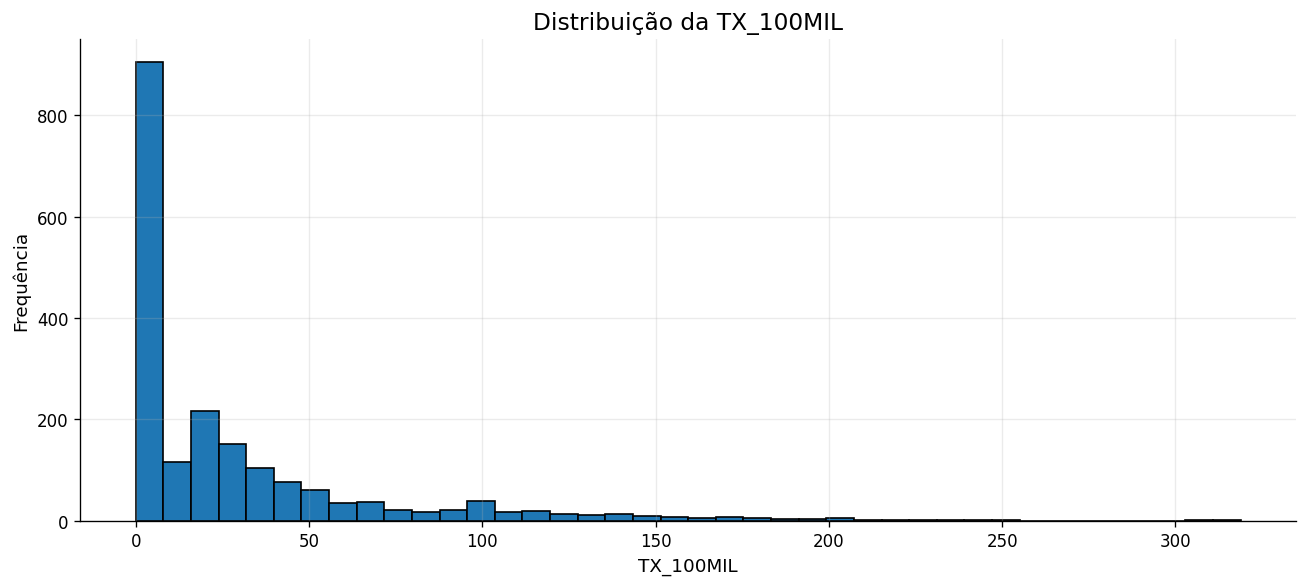

In [ ]:
plt.figure(figsize=(11, 5))
plt.hist(df_anual['TX_100MIL'].dropna(), bins=40, edgecolor='black')
plt.title('Distribuição da TX_100MIL')
plt.xlabel('TX_100MIL')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

### 3.3.1 - Análise do gráfico

Se a distribuição apresentar assimetria à direita, isso indica que muitos registros se concentram em taxas mais baixas, enquanto poucos casos alcançam valores muito elevados.


## 3.4 - Boxplot

O boxplot será utilizado para identificar visualmente a presença de valores extremos na distribuição da variável **TX_100MIL**.


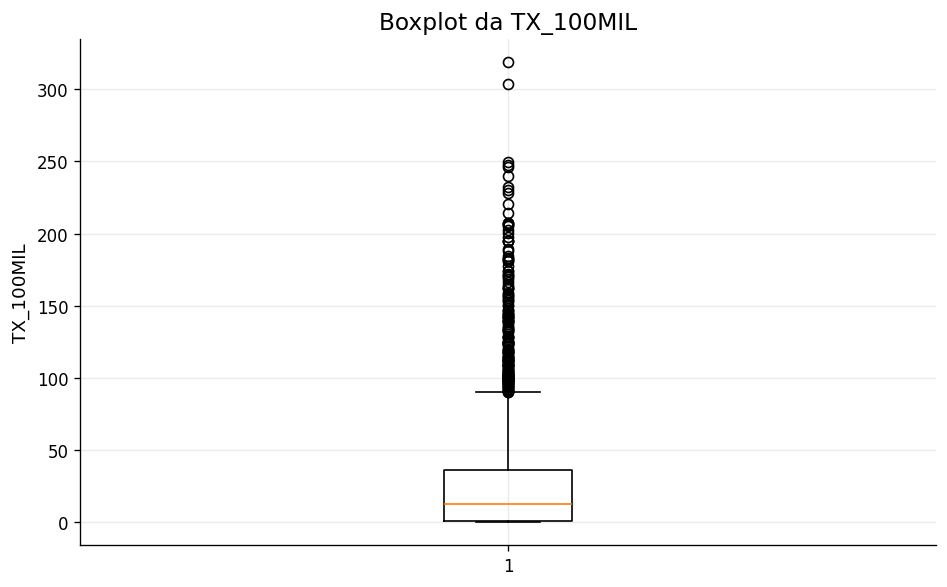

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(df_anual['TX_100MIL'].dropna(), vert=True)
plt.title('Boxplot da TX_100MIL')
plt.ylabel('TX_100MIL')
plt.tight_layout()
plt.show()

### 3.4.1 - Análise do gráfico

O boxplot permite observar a mediana, a dispersão central e os pontos extremos da variável. A presença de muitos outliers é compatível com a heterogeneidade entre estados, tipos de crime e anos.


### 3.4.2 - Verificação formal de outliers pelo método do IQR

Além da detecção visual, será utilizado o método do intervalo interquartil para formalizar a identificação de valores extremos.


In [ ]:
Q1 = df_anual['TX_100MIL'].quantile(0.25)
Q3 = df_anual['TX_100MIL'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_tx = df_anual[
    (df_anual['TX_100MIL'] < limite_inferior) |
    (df_anual['TX_100MIL'] > limite_superior)
].copy()

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)
print("Quantidade de outliers:", len(outliers_tx))

display(outliers_tx.head(20))

Q1: 0.5969645341222923
Q3: 36.39971058534912
IQR: 35.802746051226826
Limite inferior: -53.10715454271795
Limite superior: 90.10382966218936
Quantidade de outliers: 188


,UF,Tipo Crime,Ano,Ocorrências,População,TX_100MIL,TX_MEDIA_MOVEL,VAR_TX,TENDENCIA
50,Acre,Roubo de veículo,2017,849,856457,99.129320,33.043107,inf,Crescimento
51,Acre,Roubo de veículo,2018,1080,869265,124.242895,74.457405,1.253342,Crescimento
52,Acre,Roubo de veículo,2019,1246,881935,141.280253,121.550823,0.632488,Crescimento
53,Acre,Roubo de veículo,2020,836,894470,93.463168,119.662105,-0.015538,Estável
54,Acre,Roubo de veículo,2021,1035,906876,114.128062,116.290494,-0.028176,Estável
120,Alagoas,Roubo de veículo,2015,3158,3279222,96.303330,96.303330,NaN,Sem histórico
121,Alagoas,Roubo de veículo,2016,3895,3293629,118.258614,107.280972,0.113990,Crescimento
122,Alagoas,Roubo de veículo,2017,3133,3307532,94.723195,103.095047,-0.039018,Estável
123,Alagoas,Roubo de veículo,2018,3481,3322379,104.774320,105.918710,0.027389,Estável
152,Amapá,Furto de veículo,2015,877,779416,112.520143,112.520143,NaN,Sem histórico


### 3.4.3 - Análise da etapa

A aplicação do IQR permite complementar a inspeção visual com um critério estatístico objetivo. Isso é importante para demonstrar que a presença de valores extremos não decorre apenas de impressão visual.


### 3.4.4 - Comparação da distribuição com e sem outliers

Nesta etapa, a distribuição da taxa será comparada antes e depois da exclusão dos valores extremos identificados pelo critério do IQR.


In [ ]:
df_anual_sem_outliers = df_anual[
    (df_anual['TX_100MIL'] >= limite_inferior) &
    (df_anual['TX_100MIL'] <= limite_superior)
].copy()

print("Dimensão da base anual com outliers:", df_anual.shape)
print("Dimensão da base anual sem outliers:", df_anual_sem_outliers.shape)

Dimensão da base anual com outliers: (1938, 9)
Dimensão da base anual sem outliers: (1750, 9)


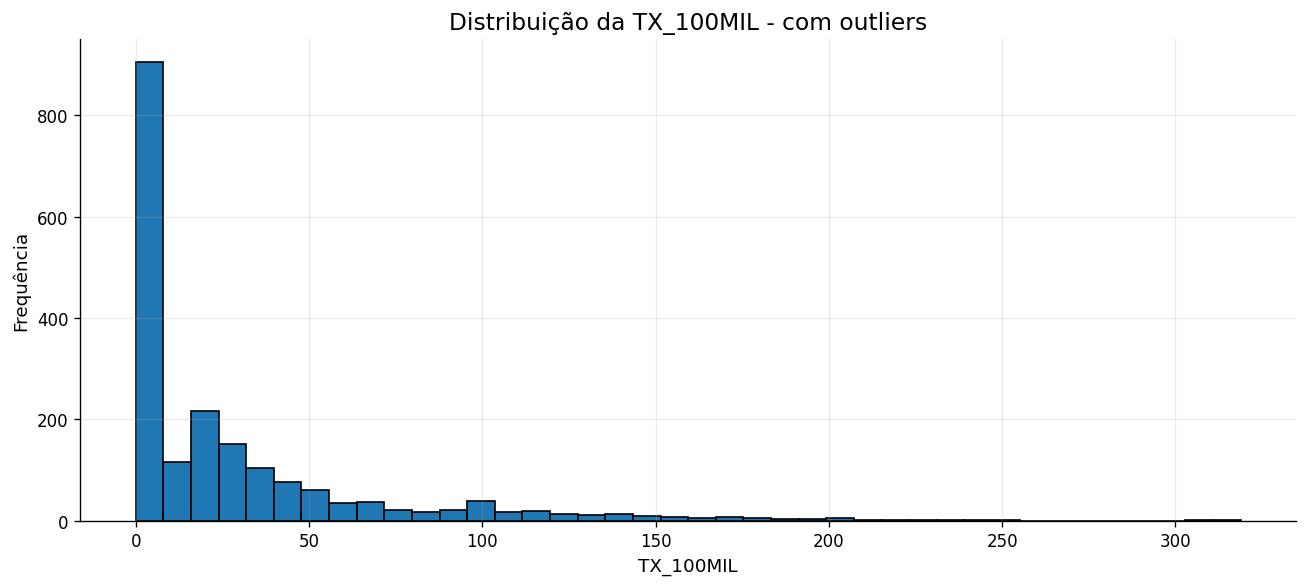

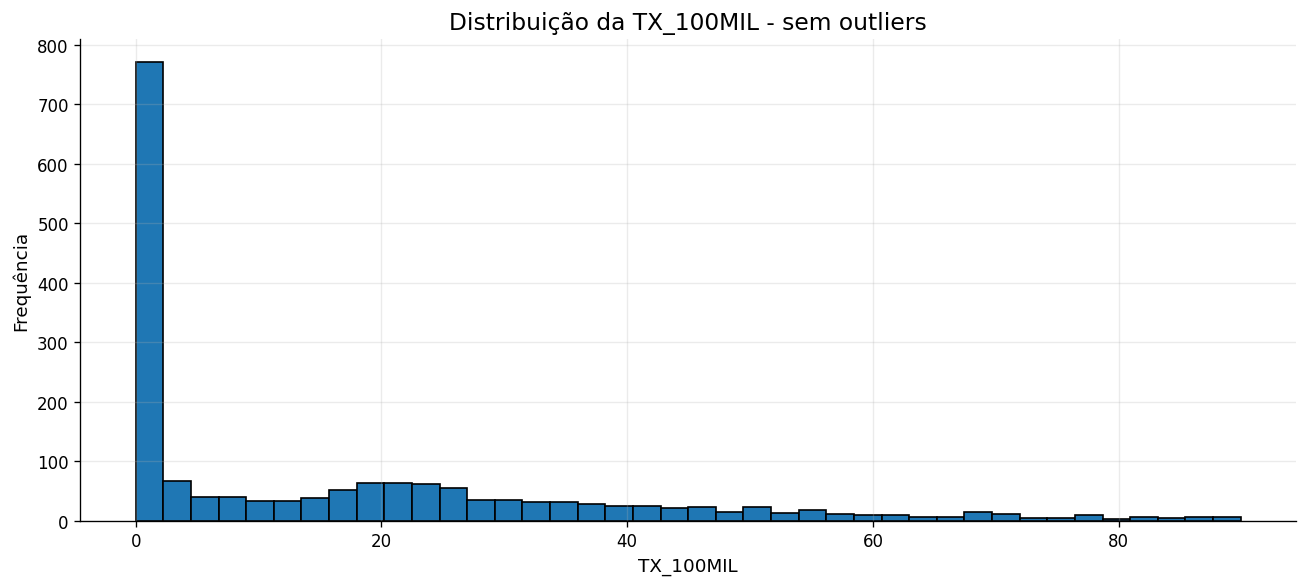

In [ ]:
plt.figure(figsize=(11, 5))
plt.hist(df_anual['TX_100MIL'].dropna(), bins=40, edgecolor='black')
plt.title('Distribuição da TX_100MIL - com outliers')
plt.xlabel('TX_100MIL')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.hist(df_anual_sem_outliers['TX_100MIL'].dropna(), bins=40, edgecolor='black')
plt.title('Distribuição da TX_100MIL - sem outliers')
plt.xlabel('TX_100MIL')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

### 3.4.5 - Análise do gráfico

A comparação ajuda a perceber o quanto os valores extremos influenciam a forma da distribuição. Em geral, a exclusão de outliers reduz a dispersão e evidencia melhor a massa principal da distribuição.


## 3.5 - Matriz de correlação

Embora o foco do trabalho seja descritivo, a matriz de correlação auxilia na observação do grau de associação linear entre as principais variáveis numéricas da base anual.


In [ ]:
colunas_corr = ['Ano', 'Ocorrências', 'População', 'TX_100MIL', 'TX_MEDIA_MOVEL', 'VAR_TX']
corr_df = df_anual[colunas_corr].copy()

matriz_corr = corr_df.corr(numeric_only=True)

print("Matriz de correlação das principais variáveis numéricas:")
display(matriz_corr)

plt.figure(figsize=(8, 6))
plt.imshow(matriz_corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(matriz_corr.columns)), matriz_corr.columns, rotation=45, ha='right')
plt.yticks(range(len(matriz_corr.index)), matriz_corr.index)
plt.title('Matriz de correlação - base anual')
plt.tight_layout()
plt.show()


### 3.5.1 - Análise da etapa

A matriz de correlação não substitui a interpretação substantiva do problema, mas ajuda a verificar relações esperadas. Em especial, é natural observar correlação positiva entre **TX_100MIL** e **TX_MEDIA_MOVEL**, pois a média móvel é derivada da própria taxa. Já a relação entre **Ocorrências** e **População** deve ser interpretada com cautela, pois ambas influenciam a taxa, mas não determinam isoladamente o nível proporcional de criminalidade.


##3.2 -  Verificação da qualidade dos dados

É imprescindível realizar a verificação de valores faltantes, inconsistências e duplicidades. Esta etapa é fundamental para garantir que a análise posterior seja confiável.

In [ ]:
print("Valores faltantes por coluna - base criminal:")
display(df_criminal.isna().sum().to_frame("qtd_nulos"))

print("Quantidade de linhas duplicadas na base criminal:", df_criminal.duplicated().sum())

Valores faltantes por coluna - base criminal:


,qtd_nulos
UF,0
Tipo Crime,0
Ano,0
Mês,0
Ocorrências,0


Quantidade de linhas duplicadas na base criminal: 0


In [ ]:
print("Valores únicos de UF:")
display(pd.DataFrame(sorted(df_criminal['UF'].unique()), columns=['UF']))

print("Valores únicos de Tipo Crime:")
display(pd.DataFrame(sorted(df_criminal['Tipo Crime'].unique()), columns=['Tipo Crime']))

print("Valores únicos de Mês:")
display(pd.DataFrame(sorted(df_criminal['Mês'].unique()), columns=['Mês']))

Valores únicos de UF:


,UF
0,Acre
1,Alagoas
2,Amapá
3,Amazonas
4,Bahia
5,Ceará
6,Distrito Federal
7,Espírito Santo
8,Goiás
9,Maranhão


Valores únicos de Tipo Crime:


,Tipo Crime
0,Estupro
1,Furto de veículo
2,Homicídio doloso
3,Lesão corporal seguida de morte
4,Roubo a instituição financeira
5,Roubo de carga
6,Roubo de veículo
7,Roubo seguido de morte (latrocínio)
8,Tentativa de homicídio


Valores únicos de Mês:


,Mês
0,abril
1,agosto
2,dezembro
3,fevereiro
4,janeiro
5,julho
6,junho
7,maio
8,março
9,novembro


###3.2.1 - Análise da etapa

A verificação de nulos e duplicidades permite identificar se existem problemas estruturais básicos. Caso não existam valores faltantes relevantes e duplicidades indevidas, isso fortalece a confiabilidade da base.

A inspeção dos valores únicos também é importante para verificar a consistência textual das categorias. Em bases reais, é comum encontrar variações de grafia, espaços indevidos ou categorias duplicadas semanticamente. Nesta etapa, a estrutura categórica parece coerente com o contexto do problema.

### 3.6.2 - Verificação final de valores faltantes na base anual

Como última checagem de qualidade, será avaliada a quantidade de valores faltantes remanescentes na base anual consolidada.


In [ ]:
nulos_anual = df_anual.isna().sum().sort_values(ascending=False)

print("Valores faltantes por coluna - base anual:")
display(nulos_anual.to_frame('qtd_nulos'))

Valores faltantes por coluna - base anual:


,qtd_nulos
VAR_TX,248
UF,0
Tipo Crime,0
Ano,0
População,0
Ocorrências,0
TX_100MIL,0
TX_MEDIA_MOVEL,0
TENDENCIA,0
REGIAO,0


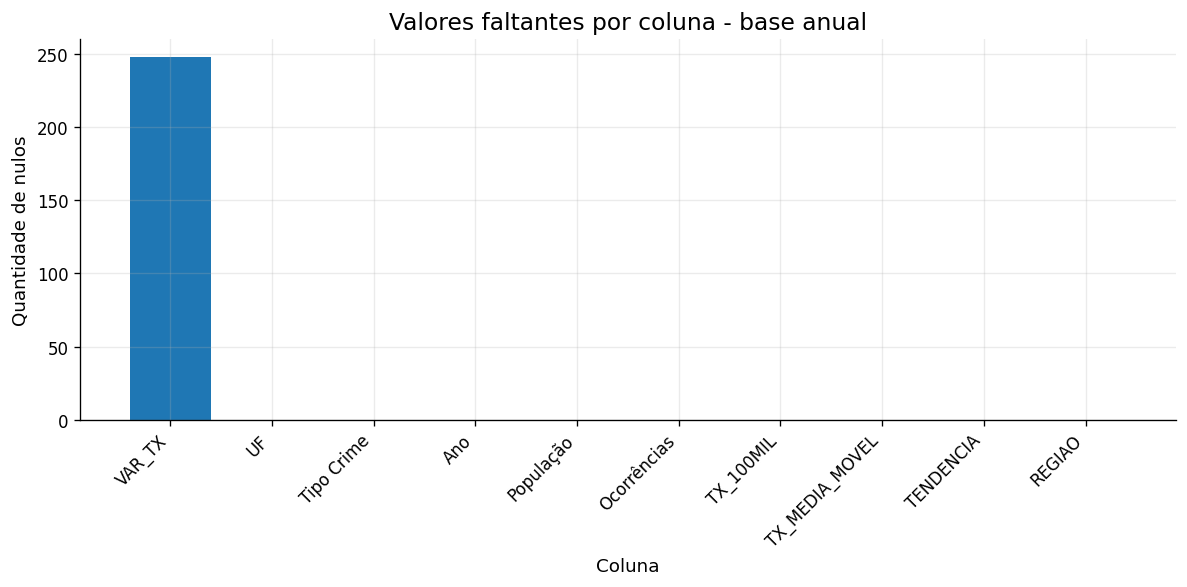

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(nulos_anual.index, nulos_anual.values)
plt.title('Valores faltantes por coluna - base anual')
plt.xlabel('Coluna')
plt.ylabel('Quantidade de nulos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.6.3 - Análise da etapa

Essa checagem final permite confirmar que os valores ausentes observados em **VAR_TX** são esperados e metodologicamente justificáveis. Como a variável **TENDENCIA** foi preenchida com a categoria **"Sem histórico"** nesses casos, ela deixa de apresentar nulos sem comprometer a coerência analítica da base.


## 3.7 - Distribuição da variável TENDENCIA

Esta etapa verifica a frequência das classes da variável **TENDENCIA**, o que é importante tanto para a interpretação analítica quanto para eventuais estudos futuros de classificação.


In [ ]:
dist_tendencia = df_anual['TENDENCIA'].value_counts(dropna=False)

print("Distribuição da variável TENDENCIA:")
display(dist_tendencia.to_frame('frequencia'))

Distribuição da variável TENDENCIA:


,frequencia
TENDENCIA,
Queda,794
Estável,493
Crescimento,403
Sem histórico,248


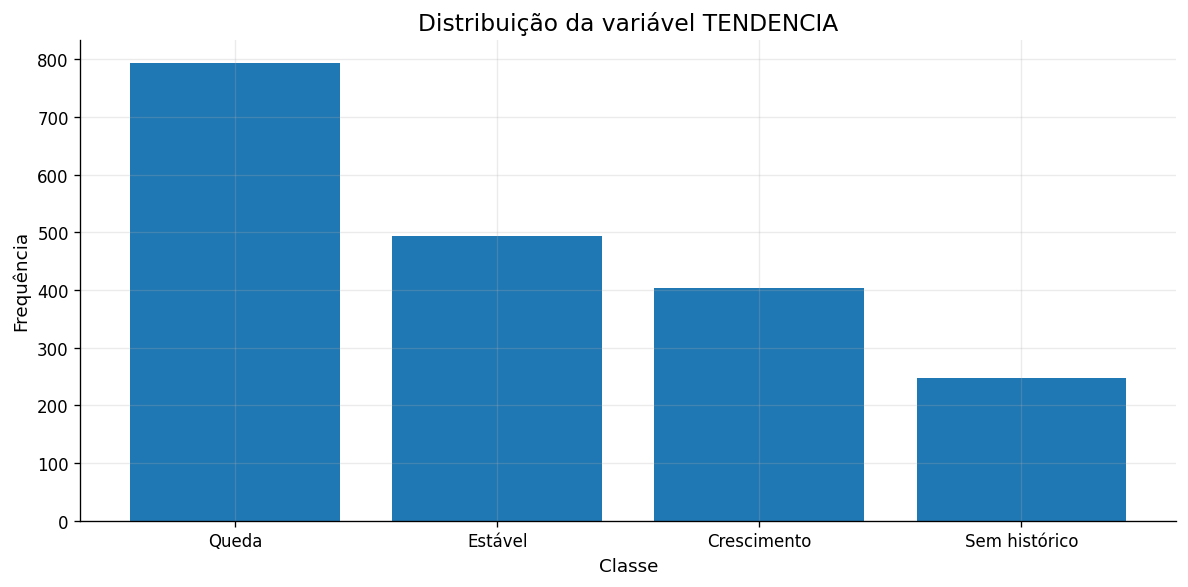

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(dist_tendencia.index.astype(str), dist_tendencia.values)
plt.title('Distribuição da variável TENDENCIA')
plt.xlabel('Classe')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

### 3.7.1 - Análise do gráfico

Nesse gráfico, a categoria **"Sem histórico"** aparece porque ela faz parte da base final e representa todos os registros em que não foi possível calcular variação percentual.

Essa visualização é válida para documentação metodológica, mas não deve ser usada como gráfico principal para análise substantiva da tendência.


### 3.7.2 - Análise da etapa

A distribuição das classes permite verificar se existe predominância de crescimento, queda ou estabilidade. Isso é relevante porque uma forte concentração em apenas uma classe poderia indicar desbalanceamento, o que seria importante em possíveis aplicações futuras de aprendizado supervisionado.


### 3.7.3 - Visão analítica da distribuição da TENDENCIA

Para a análise substantiva da tendência da criminalidade, os registros classificados como **"Sem histórico"** são excluídos da visualização.

Essa decisão é necessária porque tais registros não expressam crescimento, queda ou estabilidade, apenas ausência de base comparativa anterior.


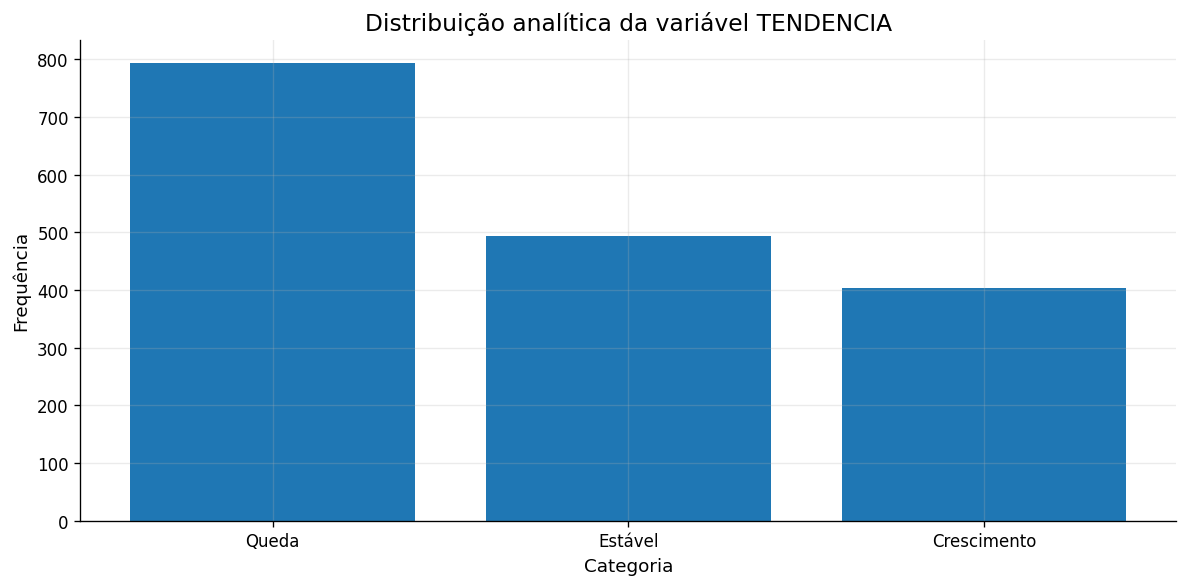

,frequencia
TENDENCIA,
Queda,794
Estável,493
Crescimento,403


In [ ]:
df_tend_plot = df_anual[df_anual['TENDENCIA'] != 'Sem histórico'].copy()

dist_tendencia_analitica = df_tend_plot['TENDENCIA'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(dist_tendencia_analitica.index, dist_tendencia_analitica.values)
plt.title('Distribuição analítica da variável TENDENCIA')
plt.xlabel('Categoria')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

display(dist_tendencia_analitica.to_frame('frequencia'))

### 3.7.4 - Observação

A exclusão de **"Sem histórico"** foi feita apenas para fins de visualização analítica. Na base de dados, essa categoria foi mantida para preservar a rastreabilidade metodológica do processo e evitar que a ausência de histórico anterior fosse confundida com ausência de dado.


## 3.8 - Ocorrências totais por tipo de crime

O primeiro gráfico tem como objetivo identificar quais tipos de crime concentram o maior volume absoluto de registros ao longo do período analisado.


In [ ]:
crimes_abs = (
    df_criminal
    .groupby('Tipo Crime', as_index=False)['Ocorrências']
    .sum()
    .sort_values('Ocorrências', ascending=True)
)

print("Ocorrências totais por tipo de crime:")
display(crimes_abs)

Ocorrências totais por tipo de crime:


,Tipo Crime,Ocorrências
4,Roubo a instituição financeira,5298
3,Lesão corporal seguida de morte,6100
7,Roubo seguido de morte (latrocínio),14263
5,Roubo de carga,148342
8,Tentativa de homicídio,289959
2,Homicídio doloso,354868
0,Estupro,406831
6,Roubo de veículo,1633495
1,Furto de veículo,1851837


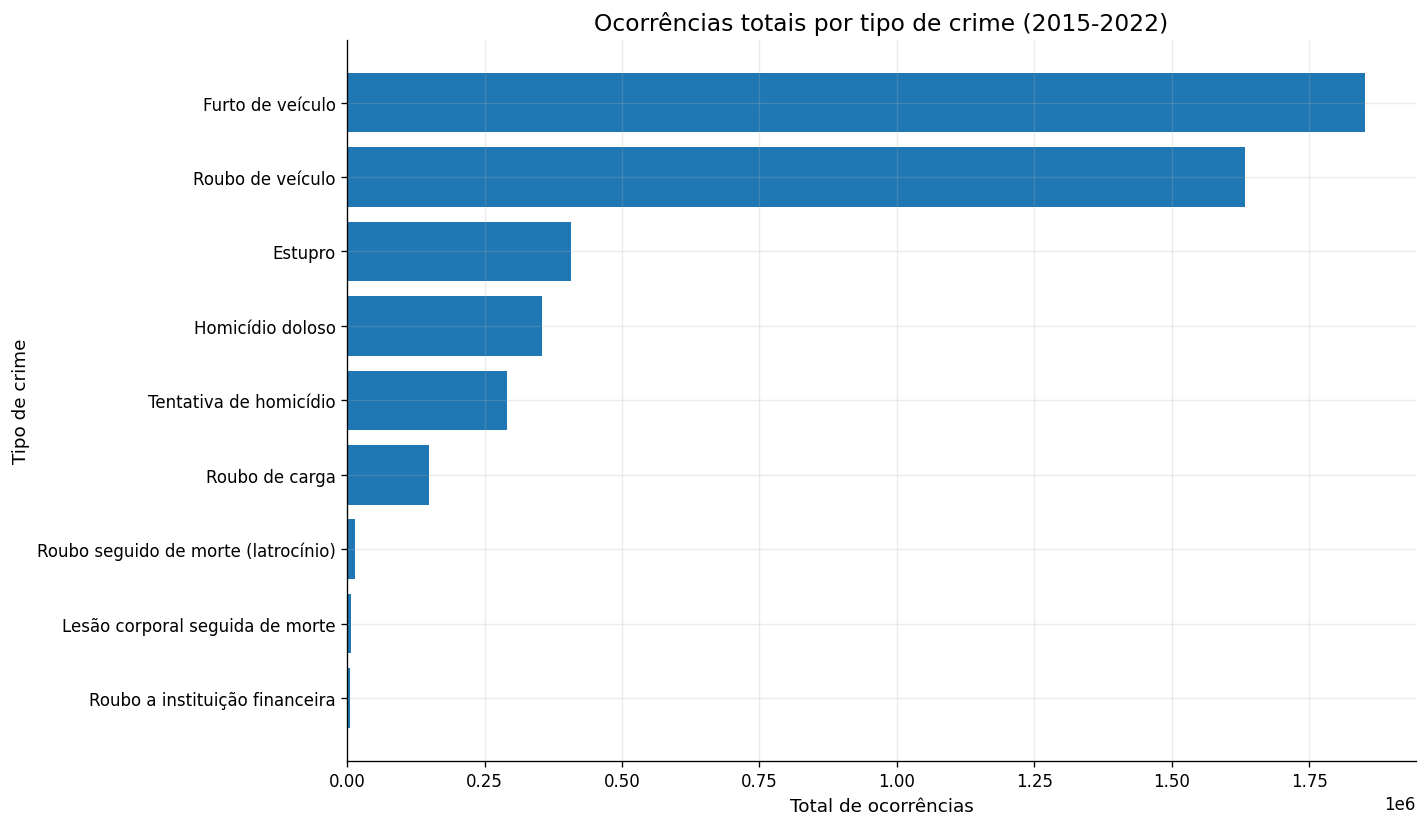

In [ ]:
plt.figure(figsize=(12, 7))
plt.barh(crimes_abs['Tipo Crime'], crimes_abs['Ocorrências'])
plt.title('Ocorrências totais por tipo de crime (2015-2022)')
plt.xlabel('Total de ocorrências')
plt.ylabel('Tipo de crime')
plt.tight_layout()
plt.show()

### 3.8.1 - Análise do gráfico

Esse gráfico mostra a composição geral do fenômeno estudado, permitindo identificar quais crimes são mais frequentes em números absolutos.


## 3.9 - Taxa média anual por tipo de crime

Nesta etapa, o volume absoluto é substituído pela taxa média anual por 100 mil habitantes, permitindo uma leitura proporcional do comportamento dos diferentes tipos de crime.


In [ ]:
crimes_taxa = (
    df_anual
    .groupby('Tipo Crime', as_index=False)['TX_100MIL']
    .mean()
    .sort_values('TX_100MIL', ascending=True)
)

print("Taxa média anual por tipo de crime:")
display(crimes_taxa)

Taxa média anual por tipo de crime:


,Tipo Crime,TX_100MIL
4,Roubo a instituição financeira,0.429279
3,Lesão corporal seguida de morte,0.555325
7,Roubo seguido de morte (latrocínio),1.117361
5,Roubo de carga,3.668031
8,Tentativa de homicídio,21.466098
2,Homicídio doloso,26.117798
0,Estupro,27.505952
6,Roubo de veículo,85.936284
1,Furto de veículo,88.427600


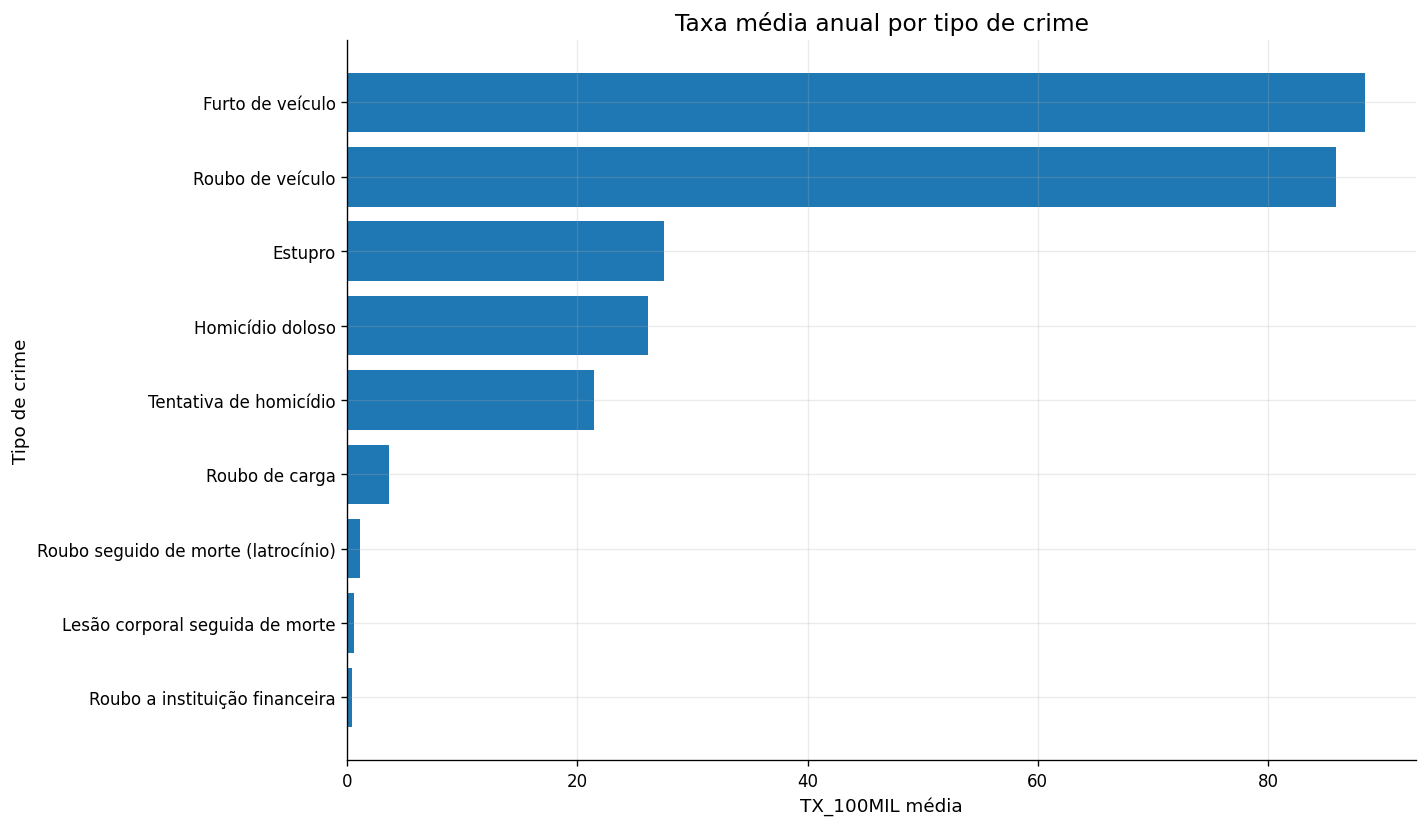

In [ ]:
plt.figure(figsize=(12, 7))
plt.barh(crimes_taxa['Tipo Crime'], crimes_taxa['TX_100MIL'])
plt.title('Taxa média anual por tipo de crime')
plt.xlabel('TX_100MIL média')
plt.ylabel('Tipo de crime')
plt.tight_layout()
plt.show()

### 3.9.1 - Análise do gráfico

Esse gráfico permite uma leitura mais refinada que a anterior, pois introduz a dimensão proporcional por meio da taxa.


## 3.10 - Evolução da taxa média anual ao longo do tempo

Será analisada agora a evolução temporal da taxa média anual de criminalidade, considerando todos os tipos de crime e UFs.


In [ ]:
evolucao_ano = (
    df_anual
    .groupby('Ano', as_index=False)['TX_100MIL']
    .mean()
)

print("Evolução da taxa média anual:")
display(evolucao_ano)

Evolução da taxa média anual:


,Ano,TX_100MIL
0,2015,31.059587
1,2016,34.094882
2,2017,33.724436
3,2018,31.484870
4,2019,27.079307
5,2020,22.981120
6,2021,23.340083
7,2022,23.866329


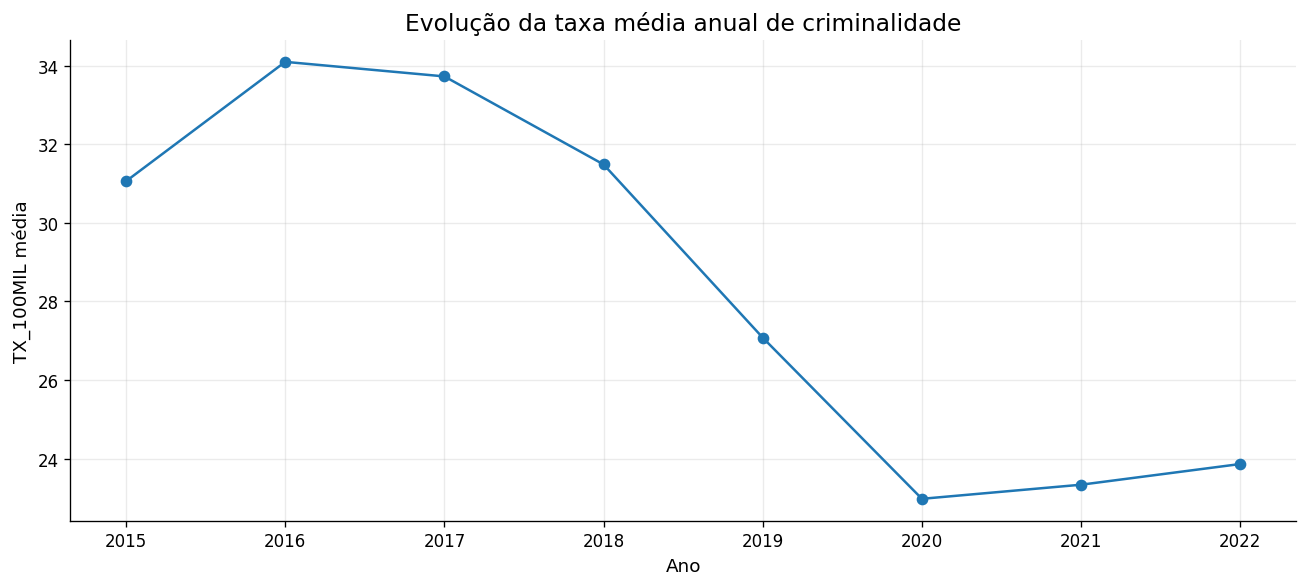

In [ ]:
plt.figure(figsize=(11, 5))
plt.plot(evolucao_ano['Ano'], evolucao_ano['TX_100MIL'], marker='o')
plt.title('Evolução da taxa média anual de criminalidade')
plt.xlabel('Ano')
plt.ylabel('TX_100MIL média')
plt.xticks(evolucao_ano['Ano'])
plt.tight_layout()
plt.show()

### 3.10.1 - Análise do gráfico

A série temporal permite observar se o comportamento médio da criminalidade apresentou tendência de crescimento, queda ou estabilidade ao longo dos anos.


## 3.11 - Top 10 UFs por taxa média anual

A seguir, serão identificadas as unidades da federação com maior taxa média anual de criminalidade no período analisado.


In [ ]:
top_ufs_taxa = (
    df_anual
    .groupby('UF', as_index=False)['TX_100MIL']
    .mean()
    .sort_values('TX_100MIL', ascending=False)
    .head(10)
    .sort_values('TX_100MIL', ascending=True)
)

print("Top 10 UFs por taxa média anual:")
display(top_ufs_taxa)

Top 10 UFs por taxa média anual:


,UF,TX_100MIL
13,Paraná,32.560087
16,Pernambuco,32.586219
8,Goiás,33.958872
22,Roraima,34.896210
7,Espírito Santo,35.468975
19,Rio Grande do Sul,35.860586
6,Distrito Federal,39.448267
21,Rondônia,40.158152
25,São Paulo,43.040062
20,Rio de Janeiro,46.379130


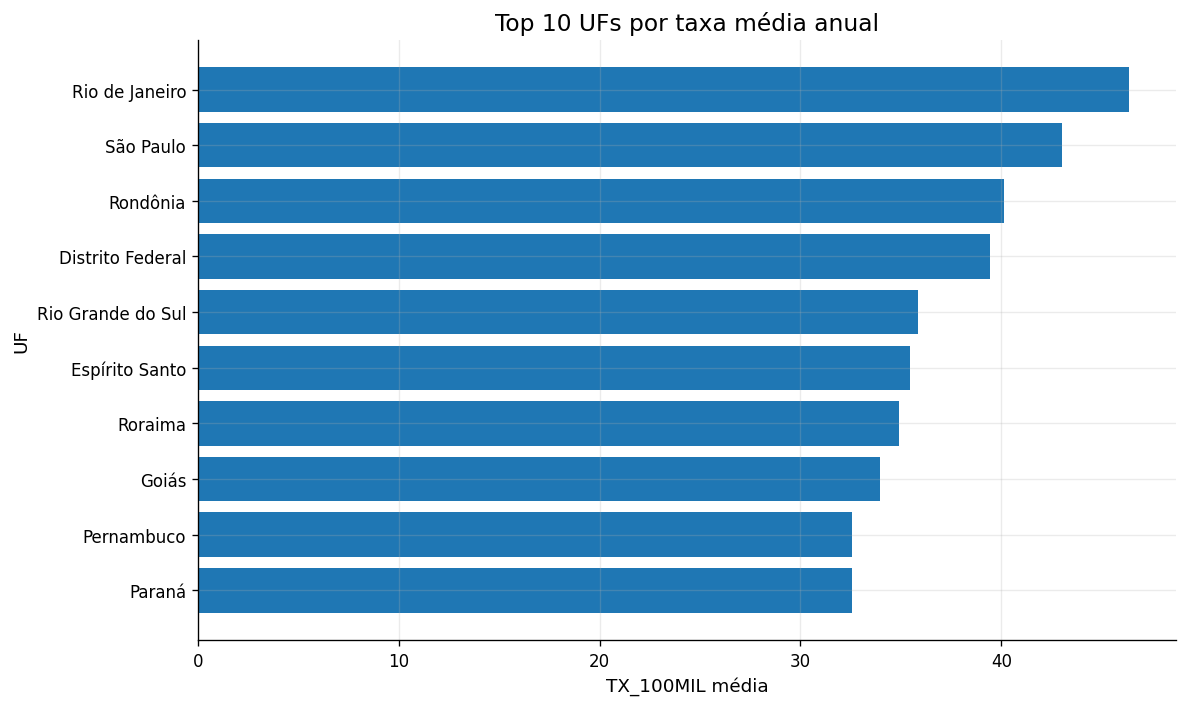

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(top_ufs_taxa['UF'], top_ufs_taxa['TX_100MIL'])
plt.title('Top 10 UFs por taxa média anual')
plt.xlabel('TX_100MIL média')
plt.ylabel('UF')
plt.tight_layout()
plt.show()

### 3.11.1 - Análise do gráfico

Esse ranking evidencia quais estados apresentam maior incidência proporcional de criminalidade, considerando o ajuste por população.


## 3.12 - Top 10 UFs por ocorrências absolutas

Para efeito de comparação, será exibido também o ranking dos estados com maior volume absoluto de ocorrências.


In [ ]:
top_ufs_abs = (
    df_criminal
    .groupby('UF', as_index=False)['Ocorrências']
    .sum()
    .sort_values('Ocorrências', ascending=False)
    .head(10)
    .sort_values('Ocorrências', ascending=True)
)

print("Top 10 UFs por ocorrências absolutas:")
display(top_ufs_abs)

Top 10 UFs por ocorrências absolutas:


,UF,Ocorrências
15,Pará,130529
5,Ceará,159694
8,Goiás,168116
16,Pernambuco,223280
4,Bahia,237443
13,Paraná,255089
19,Rio Grande do Sul,292162
12,Minas Gerais,307426
20,Rio de Janeiro,573431
25,São Paulo,1391783


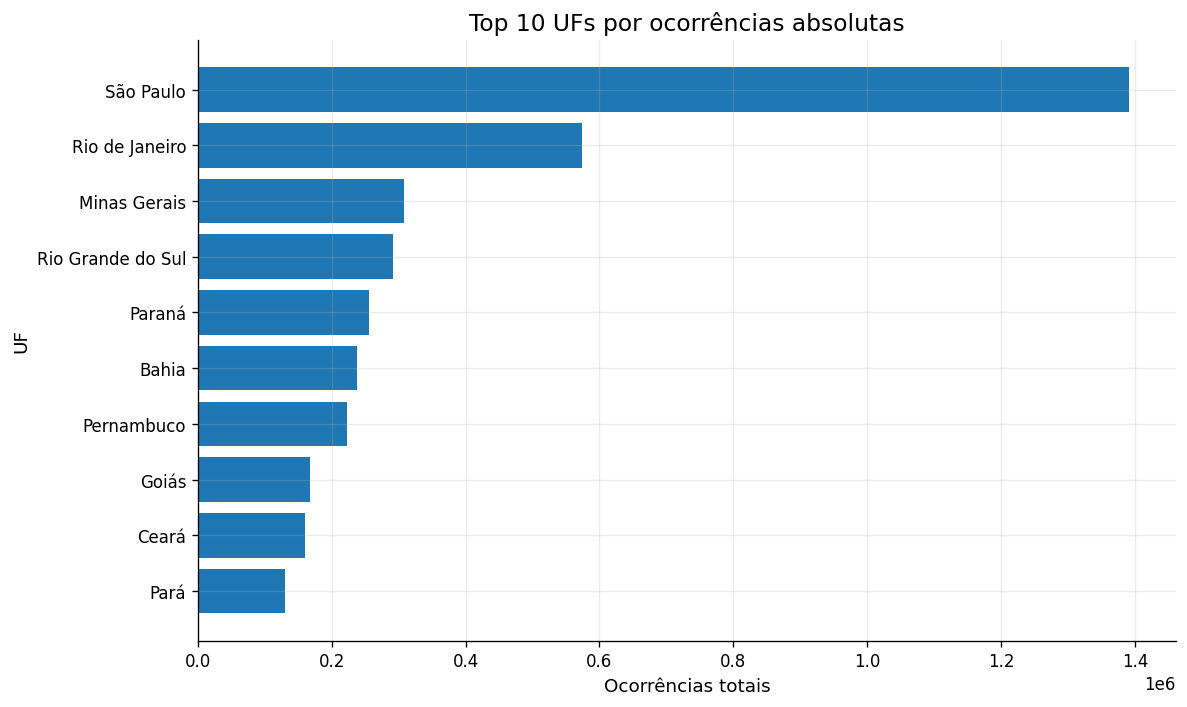

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(top_ufs_abs['UF'], top_ufs_abs['Ocorrências'])
plt.title('Top 10 UFs por ocorrências absolutas')
plt.xlabel('Ocorrências totais')
plt.ylabel('UF')
plt.tight_layout()
plt.show()

### 3.12.1 - Análise do gráfico

A comparação entre esse ranking e o ranking por taxa é essencial para demonstrar o efeito da padronização. Estados muito populosos tendem a ocupar posições elevadas em números absolutos, mas isso não significa necessariamente maior incidência proporcional.


## 3.13 - Sazonalidade mensal das ocorrências

Como a base original possui detalhamento mensal, será analisado se existe concentração das ocorrências em determinados meses do ano.


In [ ]:
mapa_meses = {
    'janeiro': 1, 'fevereiro': 2, 'março': 3, 'abril': 4,
    'maio': 5, 'junho': 6, 'julho': 7, 'agosto': 8,
    'setembro': 9, 'outubro': 10, 'novembro': 11, 'dezembro': 12
}

df_mensal['MES_NUM'] = df_mensal['Mês'].map(mapa_meses)

sazonalidade = (
    df_mensal
    .groupby(['MES_NUM', 'Mês'], as_index=False)['Ocorrências']
    .sum()
    .sort_values('MES_NUM')
)

print("Sazonalidade mensal das ocorrências:")
display(sazonalidade)

Sazonalidade mensal das ocorrências:


,MES_NUM,Mês,Ocorrências
0,1,janeiro,412479
1,2,fevereiro,383929
2,3,março,417407
3,4,abril,388971
4,5,maio,392156
5,6,junho,373464
6,7,julho,381979
7,8,agosto,378742
8,9,setembro,381648
9,10,outubro,404417


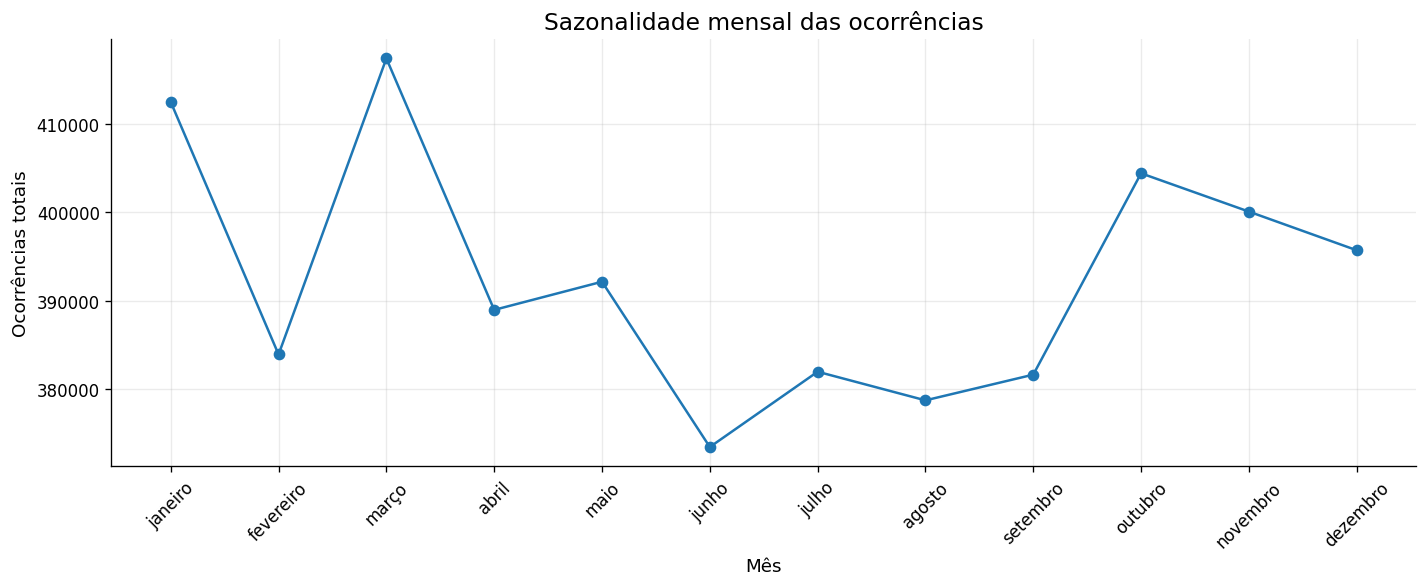

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(sazonalidade['Mês'], sazonalidade['Ocorrências'], marker='o')
plt.title('Sazonalidade mensal das ocorrências')
plt.xlabel('Mês')
plt.ylabel('Ocorrências totais')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.13.1 - Análise do gráfico

A análise mensal permite observar possíveis padrões sazonais. Caso alguns meses apresentem sistematicamente mais ocorrências, isso pode sugerir influência de fatores sazonais ou operacionais no registro dos crimes.


## 3.14 - Evolução temporal por tipo de crime

Para aprofundar a análise temporal, serão observados alguns dos tipos de crime com maior volume absoluto, permitindo comparar suas trajetórias ao longo do tempo.


In [ ]:
top4_crimes = (
    df_criminal
    .groupby('Tipo Crime', as_index=False)['Ocorrências']
    .sum()
    .sort_values('Ocorrências', ascending=False)
    .head(4)['Tipo Crime']
    .tolist()
)

print("Tipos de crime selecionados para comparação temporal:")
display(pd.DataFrame(top4_crimes, columns=['Tipo Crime']))

Tipos de crime selecionados para comparação temporal:


,Tipo Crime
0,Furto de veículo
1,Roubo de veículo
2,Estupro
3,Homicídio doloso


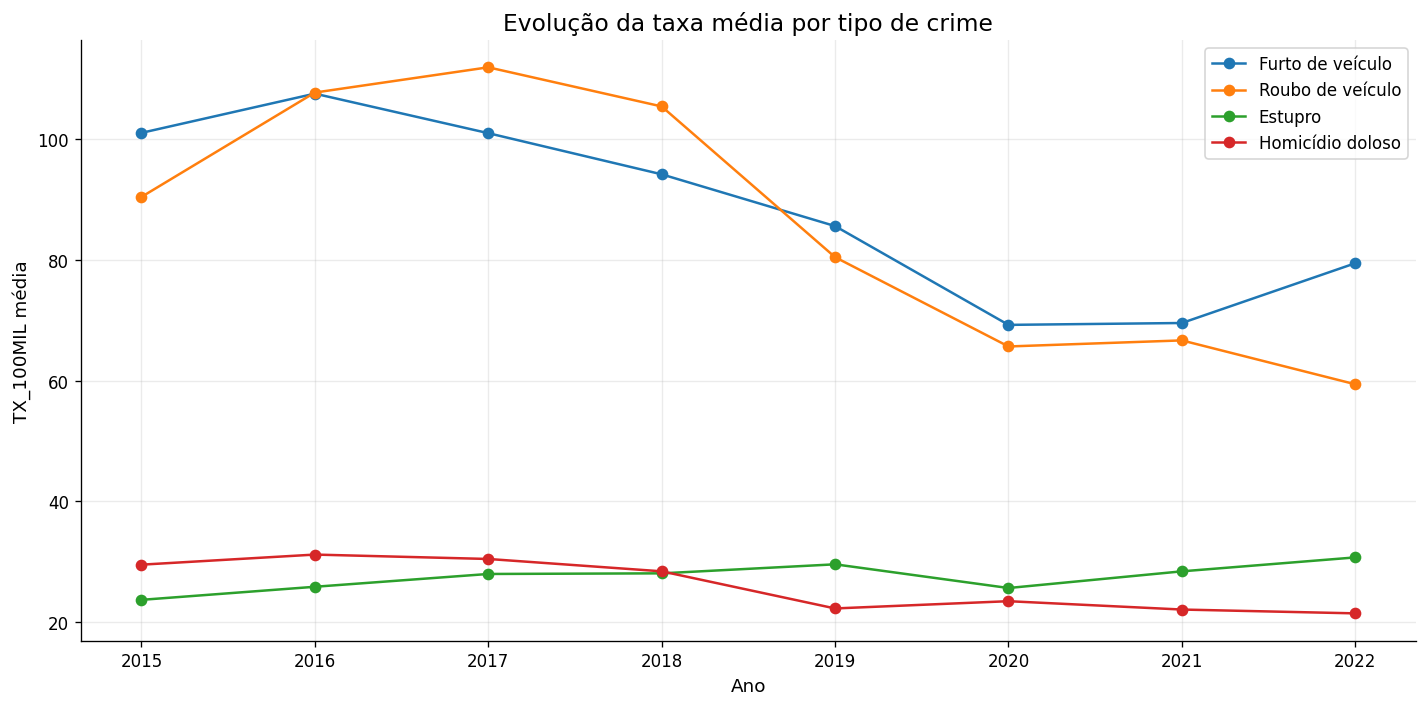

In [ ]:
plt.figure(figsize=(12, 6))

for crime in top4_crimes:
    serie = (
        df_anual[df_anual['Tipo Crime'] == crime]
        .groupby('Ano', as_index=False)['TX_100MIL']
        .mean()
    )
    plt.plot(serie['Ano'], serie['TX_100MIL'], marker='o', label=crime)

plt.title('Evolução da taxa média por tipo de crime')
plt.xlabel('Ano')
plt.ylabel('TX_100MIL média')
plt.xticks(sorted(df_anual['Ano'].unique()))
plt.legend()
plt.tight_layout()
plt.show()

### 3.14.1 - Análise do gráfico

Esse gráfico evidencia que diferentes categorias criminais podem seguir trajetórias distintas ao longo do período analisado.


## 3.15 - Heatmap da taxa média por UF e ano

Será construída uma matriz visual para observar simultaneamente a variação temporal e territorial da taxa média anual de criminalidade.


In [ ]:
heat_uf_ano = (
    df_anual
    .groupby(['UF', 'Ano'], as_index=False)['TX_100MIL']
    .mean()
    .pivot(index='UF', columns='Ano', values='TX_100MIL')
)

print("Matriz UF x Ano da taxa média:")
display(heat_uf_ano.head())

Matriz UF x Ano da taxa média:


Ano,2015,2016,2017,2018,2019,2020,2021,2022
UF,,,,,,,,
Acre,3.473621,6.410229,23.300125,32.594587,32.731059,22.980710,30.642435,27.972856
Alagoas,23.511674,26.320174,24.953147,23.400234,19.802080,17.917874,16.639119,20.368700
Amapá,34.080003,32.049713,27.276121,27.124970,25.605725,11.088251,19.763204,17.364746
Amazonas,20.691827,24.703722,28.476322,20.996311,17.632059,14.858952,17.259973,16.189162
Bahia,23.948596,25.135553,23.763678,22.614355,20.959881,18.944167,20.449984,22.090665


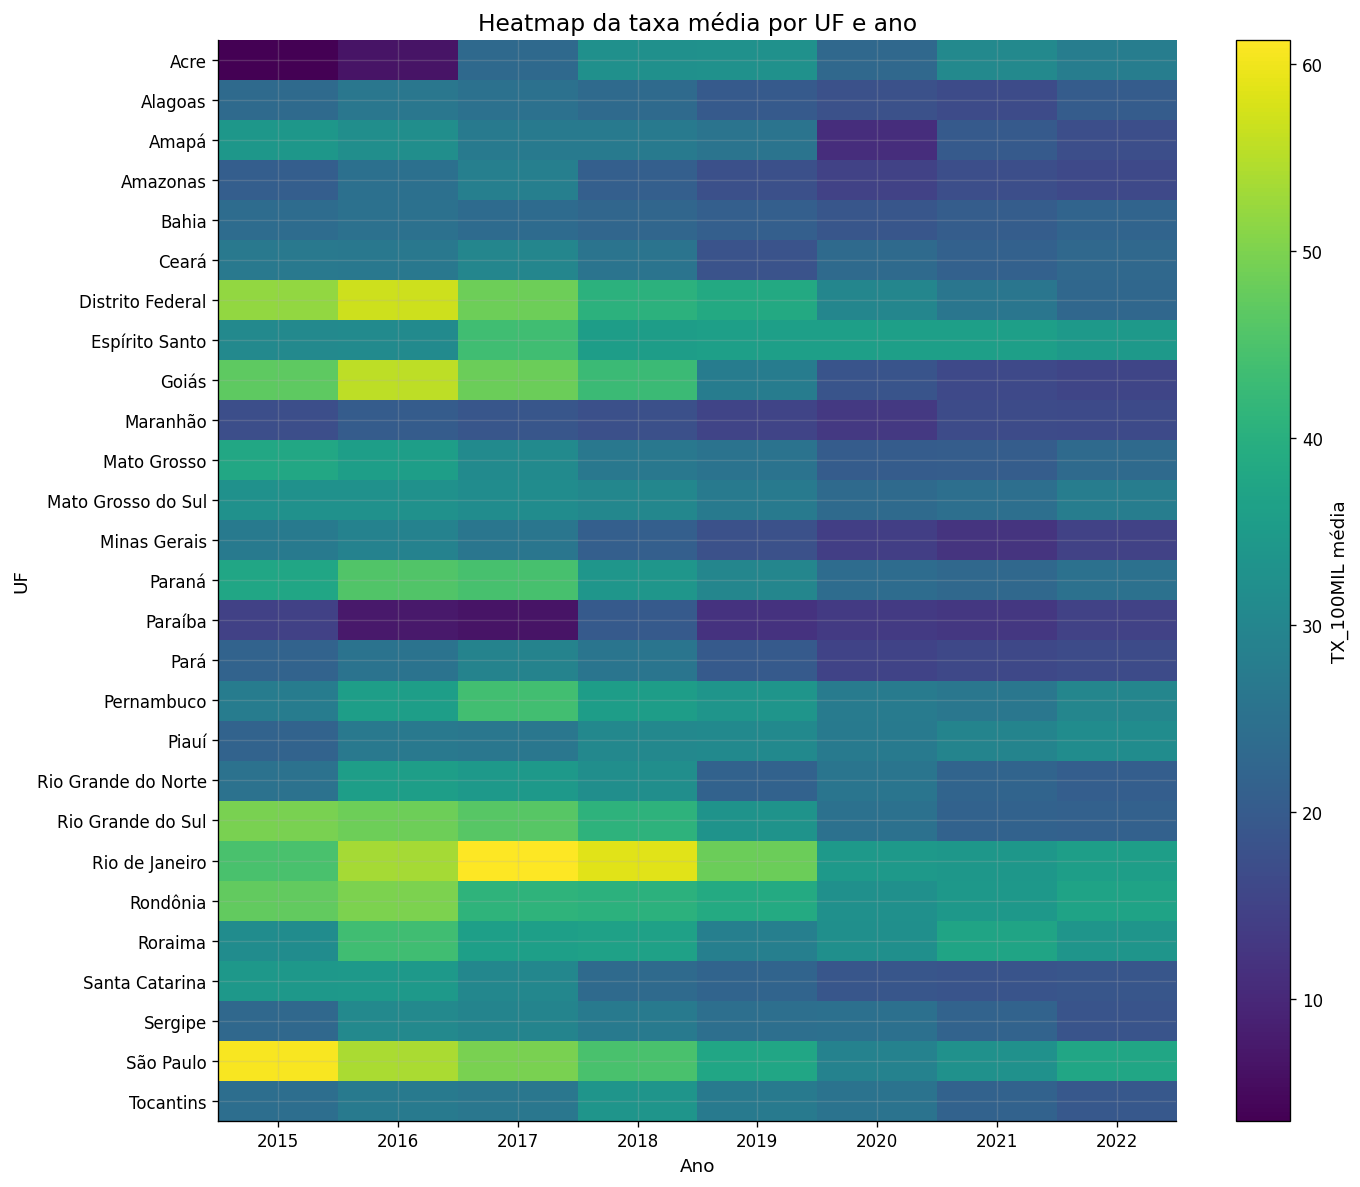

In [ ]:
plt.figure(figsize=(12, 10))
plt.imshow(heat_uf_ano, aspect='auto')
plt.colorbar(label='TX_100MIL média')
plt.title('Heatmap da taxa média por UF e ano')
plt.xlabel('Ano')
plt.ylabel('UF')
plt.xticks(range(len(heat_uf_ano.columns)), heat_uf_ano.columns)
plt.yticks(range(len(heat_uf_ano.index)), heat_uf_ano.index)
plt.tight_layout()
plt.show()

### 3.15.1 - Análise do gráfico

O heatmap permite observar de forma sintética tanto a persistência quanto a variação das taxas entre estados ao longo dos anos.


## 3.16 - Distribuição da TX_100MIL por tipo de crime

Será analisada agora a dispersão da taxa anual dentro de cada tipo de crime, permitindo comparar mediana, amplitude e presença de outliers entre categorias.


In [ ]:
dados_boxplot = []
labels_boxplot = []

for crime in sorted(df_anual['Tipo Crime'].unique()):
    dados_boxplot.append(
        df_anual.loc[df_anual['Tipo Crime'] == crime, 'TX_100MIL'].dropna()
    )
    labels_boxplot.append(crime)

/tmp/ipykernel_579/2439155907.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados_boxplot, labels=labels_boxplot, vert=True)


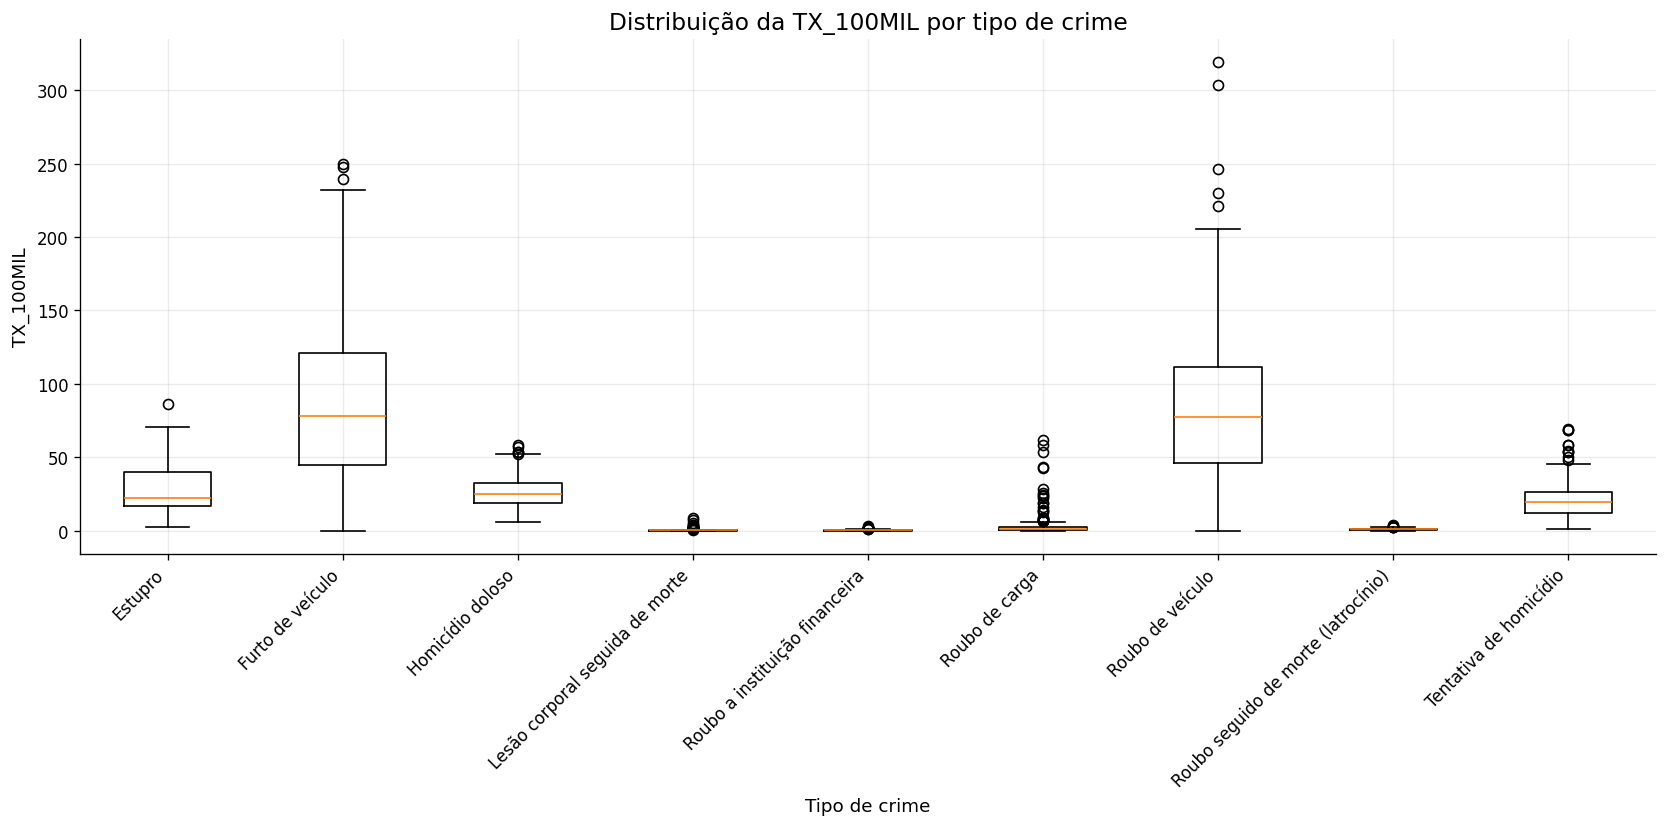

In [ ]:
plt.figure(figsize=(14, 7))
plt.boxplot(dados_boxplot, labels=labels_boxplot, vert=True)
plt.title('Distribuição da TX_100MIL por tipo de crime')
plt.xlabel('Tipo de crime')
plt.ylabel('TX_100MIL')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.16.1 - Análise do gráfico

Esse gráfico permite comparar a dispersão, a mediana e os outliers da taxa entre as diferentes categorias criminais.


## 3.17 - Distribuição anual das tendências reais

Nesta etapa, a distribuição das categorias de tendência será observada por ano, excluindo a classe **"Sem histórico"**.


In [ ]:
tendencia_por_ano = (
    df_tend_plot
    .groupby(['Ano', 'TENDENCIA'])
    .size()
    .unstack(fill_value=0)
)

print("Distribuição anual das tendências:")
display(tendencia_por_ano)

Distribuição anual das tendências:


TENDENCIA,Crescimento,Estável,Queda
Ano,,,
2016,94,97,44
2017,68,110,63
2018,69,80,93
2019,49,45,149
2020,29,42,172
2021,41,55,147
2022,53,64,126


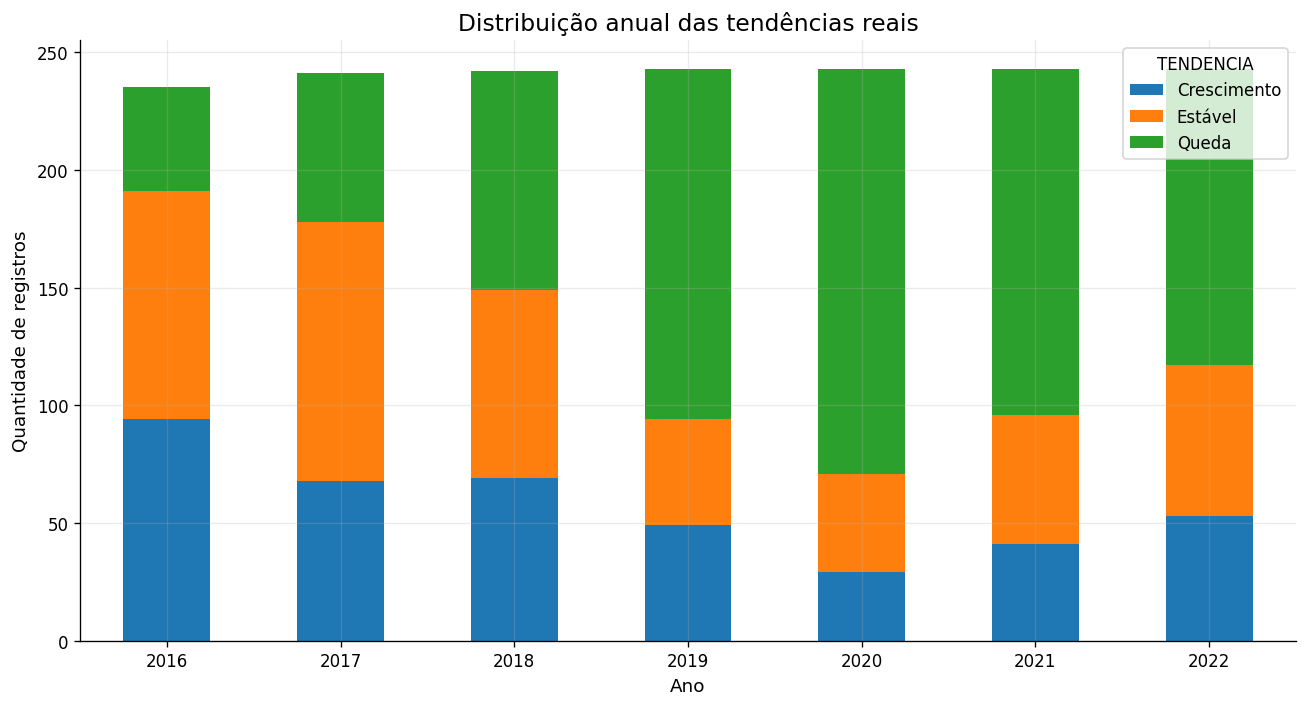

In [ ]:
tendencia_por_ano.plot(kind='bar', stacked=True, figsize=(11, 6))
plt.title('Distribuição anual das tendências reais')
plt.xlabel('Ano')
plt.ylabel('Quantidade de registros')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.17.1 - Análise do gráfico

Ao excluir **"Sem histórico"**, o gráfico passa a representar apenas mudanças reais no comportamento da taxa. Isso permite verificar se certos anos concentraram mais crescimento, mais queda ou mais estabilidade.


## 3.18 - Análise regional da taxa média anual

Para investigar diferenças territoriais mais amplas, será atribuída uma região a cada UF e calculada a taxa média anual por macrorregião.


In [ ]:
mapa_regiao = {
    'Acre': 'Norte',
    'Alagoas': 'Nordeste',
    'Amapá': 'Norte',
    'Amazonas': 'Norte',
    'Bahia': 'Nordeste',
    'Ceará': 'Nordeste',
    'Distrito Federal': 'Centro-Oeste',
    'Espírito Santo': 'Sudeste',
    'Goiás': 'Centro-Oeste',
    'Maranhão': 'Nordeste',
    'Mato Grosso': 'Centro-Oeste',
    'Mato Grosso do Sul': 'Centro-Oeste',
    'Minas Gerais': 'Sudeste',
    'Pará': 'Norte',
    'Paraíba': 'Nordeste',
    'Paraná': 'Sul',
    'Pernambuco': 'Nordeste',
    'Piauí': 'Nordeste',
    'Rio de Janeiro': 'Sudeste',
    'Rio Grande do Norte': 'Nordeste',
    'Rio Grande do Sul': 'Sul',
    'Rondônia': 'Norte',
    'Roraima': 'Norte',
    'Santa Catarina': 'Sul',
    'São Paulo': 'Sudeste',
    'Sergipe': 'Nordeste',
    'Tocantins': 'Norte'
}

df_anual['REGIAO'] = df_anual['UF'].map(mapa_regiao)

regioes_media = (
    df_anual
    .groupby('REGIAO', as_index=False)['TX_100MIL']
    .mean()
    .sort_values('TX_100MIL', ascending=True)
)

print("Taxa média anual por região:")
display(regioes_media)

Taxa média anual por região:


,REGIAO,TX_100MIL
1,Nordeste,23.430607
2,Norte,26.956840
4,Sul,31.161794
0,Centro-Oeste,32.480929
3,Sudeste,36.278081


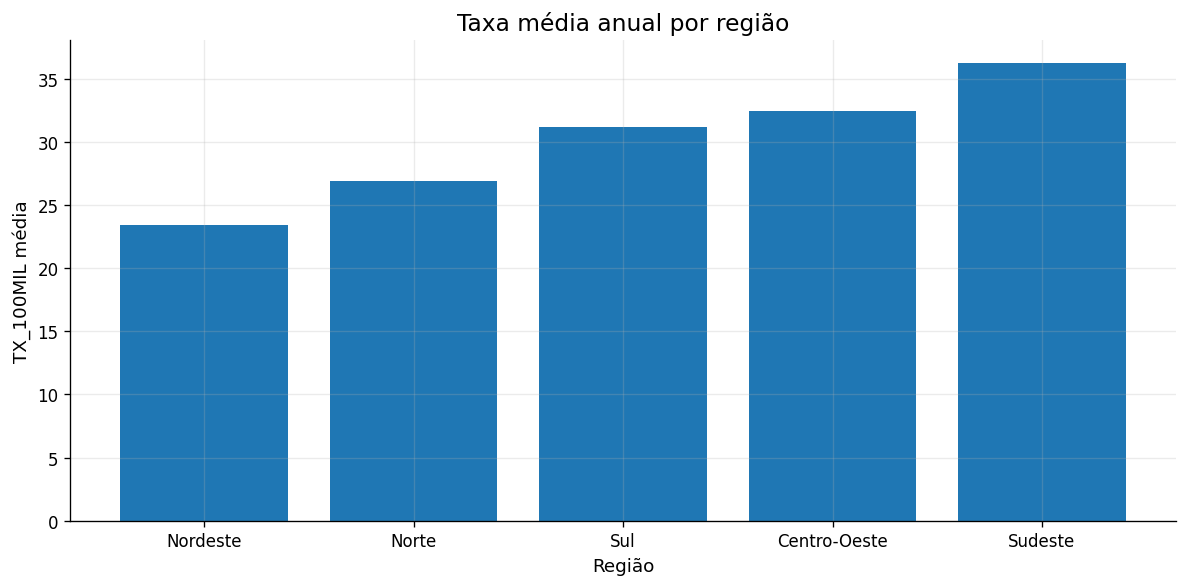

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(regioes_media['REGIAO'], regioes_media['TX_100MIL'])
plt.title('Taxa média anual por região')
plt.xlabel('Região')
plt.ylabel('TX_100MIL média')
plt.tight_layout()
plt.show()

### 3.18.1 - Análise da etapa

A análise regional complementa a leitura por UF ao revelar padrões mais amplos da distribuição territorial da criminalidade.


# 5 - Respondendo nossas hipóteses

A seguir, cada hipótese é respondida com base nas tabelas, gráficos e transformações desenvolvidos ao longo do notebook.


## 5.1 - Hipótese 1

**Hipótese:** Estados mais populosos não necessariamente apresentam as maiores taxas de criminalidade.

**Resposta:** A hipótese foi **confirmada**. A comparação entre o ranking de UFs por ocorrências absolutas e o ranking por taxa média anual mostra que estados muito populosos tendem a liderar em volume absoluto, mas não necessariamente ocupam as primeiras posições quando a análise é ajustada por população. Isso reforça a importância de separar volume bruto de incidência proporcional.


## 5.2 - Hipótese 2

**Hipótese:** A padronização por população altera significativamente a interpretação dos resultados.

**Resposta:** A hipótese foi **confirmada**. A criação da variável **TX_100MIL** modificou de forma relevante a leitura dos dados, permitindo comparações mais justas entre estados e entre tipos de crime. Os gráficos de ocorrências absolutas e de taxa média anual evidenciam que a interpretação muda quando o denominador populacional é incorporado.


## 5.3 - Hipótese 3

**Hipótese:** Existem diferenças temporais relevantes na evolução dos crimes.

**Resposta:** A hipótese foi **confirmada**. A análise da evolução da taxa média anual, da distribuição anual de tendências e das séries temporais por tipo de crime indica que o comportamento dos crimes não foi estático ao longo de 2015 a 2022. Há oscilações temporais e trajetórias distintas entre categorias criminais, o que sustenta a existência de variação temporal relevante.


## 5.4 - Hipótese 4

**Hipótese:** Há diferenças regionais importantes nos padrões de criminalidade.

**Resposta:** A hipótese foi **confirmada**. A agregação por **REGIAO** e a comparação das taxas médias anuais indicam heterogeneidade territorial. Além disso, o heatmap por UF e ano mostra persistência de níveis distintos entre estados, sugerindo que a dimensão regional é importante para interpretar a criminalidade no país.


## 5.5 - Hipótese 5

**Hipótese:** Alguns tipos de crime apresentam maior volatilidade que outros.

**Resposta:** A hipótese foi **confirmada parcialmente**. As séries temporais por tipo de crime e a distribuição das taxas por categoria mostram que algumas naturezas criminais variam mais intensamente do que outras ao longo do tempo. Ainda assim, o conceito de volatilidade aqui foi analisado de forma descritiva, sem o uso de uma métrica formal específica de variabilidade temporal para cada crime.


# 6 - Conclusão

Este trabalho apresentou uma análise exploratória e de pré-processamento de dados criminais no Brasil entre 2015 e 2022, integrando informações do SINESP e projeções populacionais do IBGE.

A principal contribuição metodológica foi a construção da variável **TX_100MIL**, que permitiu comparações proporcionais entre estados, e da variável **TENDENCIA**, que traduziu a dinâmica temporal da criminalidade em categorias interpretáveis.

As análises mostraram que o uso de números absolutos é insuficiente para compreender adequadamente o fenômeno, e que a padronização por população altera de forma relevante a leitura dos resultados. Também foram identificados outliers, diferenças regionais e indícios de padrões temporais distintos entre tipos de crime.

Do ponto de vista da disciplina, o notebook cumpre o objetivo de organizar um fluxo coerente de seleção de dados, exploração, pré-processamento e interpretação analítica, preparando a base para estudos futuros mais avançados.
